In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional

from util.reselience_metrics import (
    EvalWindows,
    to_performance,
)

In [2]:
# === DIRECT METRIC DEFINITION ===
def _pre_mean(P: pd.Series, windows: EvalWindows) -> float:
    """Calculate the mean performance before the shock."""
    mask = (P.index >= windows.pre_start) & (P.index < windows.t0)
    return float(P[mask].mean())

def recovery_time(P: pd.Series, windows: EvalWindows, target: float = 1.0) -> Optional[float]:
    """Time from t1 until P(t) reaches target * pre_mean (or None if never)."""
    pre_mu = _pre_mean(P, windows)
    thr = target * pre_mu
    mask = (P.index >= windows.t1) & (P.index <= windows.post_end)
    if not mask.any():
        return None
    P_after = P[mask]
    hit = P_after.index[P_after >= thr]
    return float(hit[0] - windows.t1) if len(hit) else None

def resilience_index(P: pd.Series, windows: EvalWindows) -> float:
    """
    Calculates the Resilience Index (R) as the normalized area under 
    the performance curve during and after the shock.
    P(t) is already normalized where 1.0 is normal performance.
    """
    mask = (P.index >= windows.t0) & (P.index <= windows.post_end)
    if not mask.any():
        return 0.0
        
    P_eval = P[mask]
    
    # Calculate Area Under the Curve (AUC)
    actual_area = np.trapz(P_eval.values, P_eval.index)
    # Calculate maximum possible area if performance stayed at exactly 1.0
    max_area = P_eval.index[-1] - P_eval.index[0]
    
    return float(actual_area / max_area) if max_area > 0 else 0.0

In [3]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
MODELS = {
    "Ours": "test_instr/dynamic_adj_normal_block/1_step_metrics.npz",
    "Ours_Normal": "test_instr/dynamic_adj_normal_normal/1_step_metrics.npz",
    "MacLight": "test_instr/maclight_normal_block/2_step_metrics.npz",
    "MAPPO": "test_instr/mappo_normal_block/3_step_metrics.npz",
    "IPPO": "test_instr/ippo_normal_block/4_step_metrics.npz",
    # "IDQN": "test_instr/idqn_normal_block/5_step_metrics.npz"
}

TIME_KEY = "t"
KEYMAP = {"speed": ("speed", "speed"), "queue": ("queue", "queue"), "wait": ("wait", "wait")}
SELECTED = ["speed", "queue", "wait"]
DIRECTION = {"speed": True, "queue": False, "wait": False}
YLABELS = {"speed": "Average speed [m/s]", "queue": "Total queue length [veh]", "wait": "Total waiting time [s]"}

EPISODE = 1
SEED = 42
SEEDS = [42, 43, 44, 45, 46]

SMOOTH_WINDOW = 60    # Smoothing window for the curves
TARGET_REC = 1      # 100% recovery

wins = EvalWindows(pre_start=0, t0=1200, t1=2400, post_end=3600)

In [4]:
def array_to_series(t: np.ndarray, x: np.ndarray) -> pd.Series:
    return pd.Series(x, index=t).sort_index()

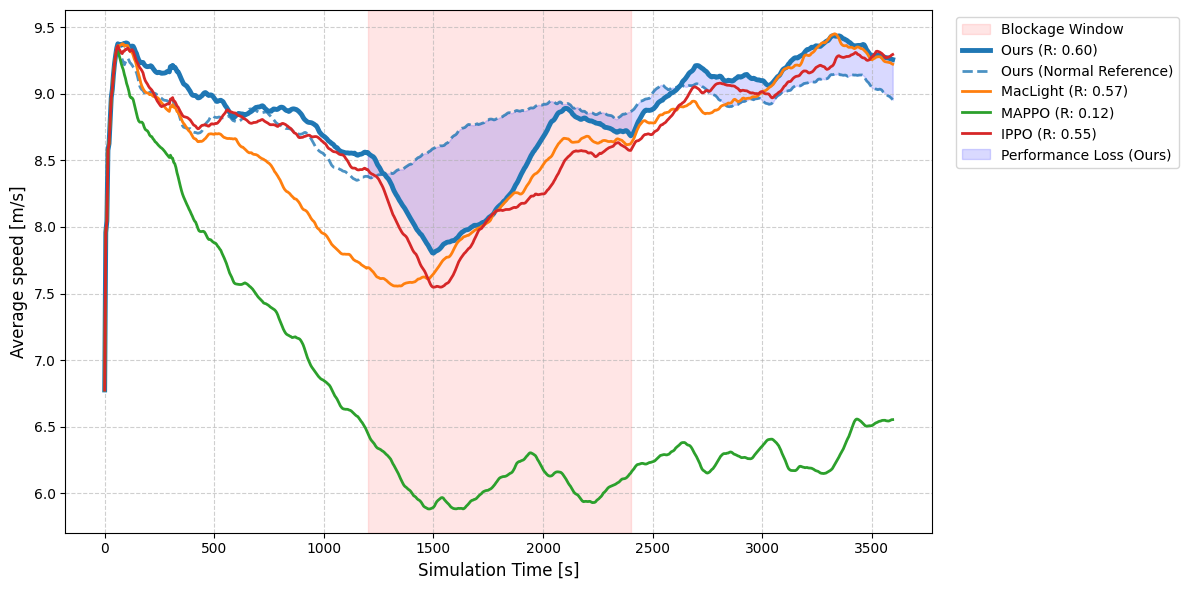

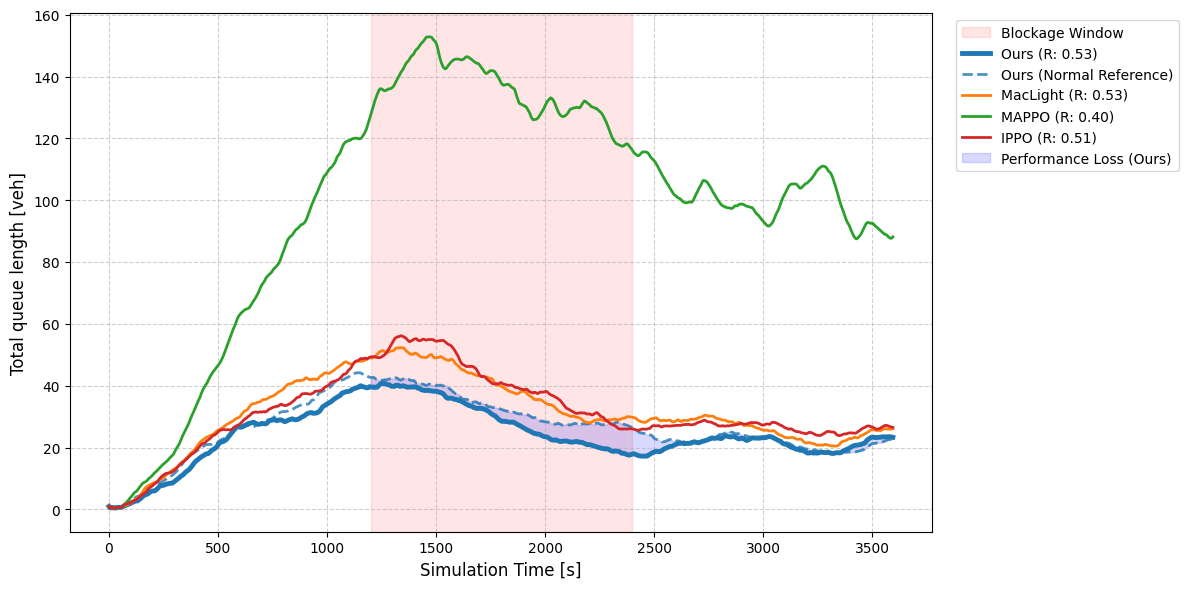

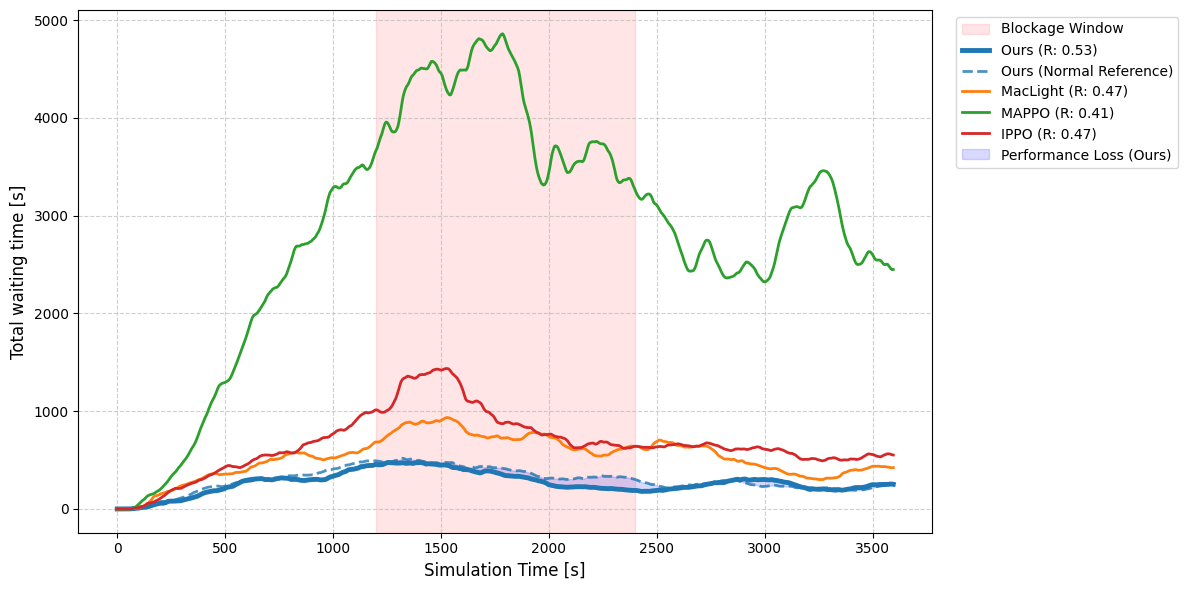

In [5]:
# === PROCESSING AND PLOTTING ===
for metric_name in SELECTED:
    plt.figure(figsize=(12, 6))
    higher_is_better = DIRECTION[metric_name]
    k_pert, _ = KEYMAP[metric_name]  # We only need the perturbed key
    
    # Shade perturbation window
    plt.axvspan(wins.t0, wins.t1, color="red", alpha=0.1, label="Blockage Window")
    
    # Dictionaries to store curves and colors for shading later
    saved_curves = {}
    ours_color = None
    
    for model_name, path_pert in MODELS.items():
        try:
            # Load file
            pert_data = np.load(path_pert, allow_pickle=True)["step_log"].item()
            
            # Extract time and metric arrays for the SINGLE SEED
            t_pert = pert_data[SEED][EPISODE][TIME_KEY]
            x_pert = pert_data[SEED][EPISODE][k_pert]
            
            series_pert = array_to_series(t_pert, x_pert)
            
            # 1) Normalize to Performance P(t)
            P = to_performance(series_pert, higher_is_better=higher_is_better, ref_window=wins.pre, allow_clip=False)
            
            # 2) Compute Recovery Time and Resilience Index
            rt_val = recovery_time(P, wins, target=TARGET_REC)
            rt_str = f"{rt_val:.0f}s" if rt_val is not None else "No Rec"
            r_val = resilience_index(P, wins)
            
            # 3) Smooth the curve for plotting
            smoothed_curve = series_pert.rolling(window=SMOOTH_WINDOW, min_periods=1).mean()
            
            # 4) Differentiate styles and save for shading
            if model_name == "Ours":
                # Plot Ours and save its generated color
                line, = plt.plot(smoothed_curve.index, smoothed_curve.values, 
                                 linewidth=3.5, label=f"{model_name} (R: {r_val:.2f})")
                ours_color = line.get_color()
                saved_curves["Ours"] = smoothed_curve
                
            elif model_name == "Ours_Normal":
                # Plot Normal Reference using the exact SAME color but dashed
                plt.plot(smoothed_curve.index, smoothed_curve.values, 
                         linewidth=2, linestyle='--', color=ours_color, alpha=0.8, 
                         label="Ours (Normal Reference)")
                saved_curves["Ours_Normal"] = smoothed_curve
                
            else:
                # Standard plotting for baselines
                plt.plot(smoothed_curve.index, smoothed_curve.values, 
                         linewidth=2, label=f"{model_name} (R: {r_val:.2f})")
                     
        except Exception as e:
            print(f"Skipping {model_name} due to error: {e}")

    # 5) Shade the area between Ours and Ours_Normal in blue
    if "Ours" in saved_curves and "Ours_Normal" in saved_curves:
        # We only want to shade from the start of the shock onwards (to represent resilience loss)
        mask = saved_curves["Ours"].index >= wins.t0
        plt.fill_between(saved_curves["Ours"].index[mask], 
                         saved_curves["Ours"].values[mask], 
                         saved_curves["Ours_Normal"].values[mask], 
                         color='blue', alpha=0.15, label="Performance Loss (Ours)")

    # Plot formatting
    plt.xlabel("Simulation Time [s]", fontsize=12)
    plt.ylabel(YLABELS.get(metric_name, metric_name), fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [3]:
import xml.etree.ElementTree as ET
from collections import defaultdict

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_ROU_FILE = "env/map/hangzhou_4x4_gudang_18041610_1h.rou.xml"  # Change this to your actual file name
OUTPUT_ROU_FILE = "hangzhou_constant.rou.xml"  # The new file that will be created

# The time window to sample the "Snapshot Demand"
WINDOW_START = 0  
WINDOW_END = 3600    
WINDOW_DURATION = WINDOW_END - WINDOW_START

# Total duration of the new constant scenario (1 hour)
SIM_END = 3600

# ==========================================
# 2. PARSE REALISTIC FILE & BUILD OD MATRIX
# ==========================================
print(f"Parsing {INPUT_ROU_FILE} for vehicles departing between {WINDOW_START}s and {WINDOW_END}s...")

tree = ET.parse(INPUT_ROU_FILE)
root = tree.getroot()

# Dictionary to hold our OD Matrix: od_matrix[(origin, destination)] = count
od_matrix = defaultdict(int)

for vehicle in root.findall('vehicle'):
    depart_time = float(vehicle.get('depart'))
    
    # Check if the vehicle departs within our snapshot window
    if WINDOW_START <= depart_time <= WINDOW_END:
        route = vehicle.find('route')
        if route is not None:
            edges = route.get('edges').split()
            if len(edges) >= 2:
                origin = edges[0]         # First edge
                destination = edges[-1]   # Last edge
                
                # Add to our OD Matrix
                od_matrix[(origin, destination)] += 1

print(f"Found {sum(od_matrix.values())} vehicles across {len(od_matrix)} unique OD pairs in the snapshot window.")

# ==========================================
# 3. GENERATE CONSTANT FLOW XML
# ==========================================
print(f"Generating constant flow file: {OUTPUT_ROU_FILE}...")

new_root = ET.Element("routes")

flow_id_counter = 0
for (origin, destination), count in od_matrix.items():
    # Extrapolate the 5-minute count to an hourly rate (vehsPerHour)
    # Example: If 5 cars depart in 5 mins, that is 60 cars per hour.
    hourly_rate = int(count * (3600 / WINDOW_DURATION))
    
    # We only create a flow if the extrapolated rate is at least 1 veh/hour
    if hourly_rate > 0:
        ET.SubElement(new_root, "flow", {
            "id": f"flow_constant_{flow_id_counter}",
            "begin": "0",
            "end": str(SIM_END),
            "from": origin,
            "to": destination,
            "vehsPerHour": str(hourly_rate)
        })
        flow_id_counter += 1

# Save the new XML file
tree_out = ET.ElementTree(new_root)
ET.indent(tree_out, space="    ", level=0) # Make it pretty and readable
tree_out.write(OUTPUT_ROU_FILE, encoding="utf-8", xml_declaration=True)

print("Done! Your constant flow scenario is ready.")

Parsing env/map/hangzhou_4x4_gudang_18041610_1h.rou.xml for vehicles departing between 0s and 3600s...
Found 2983 vehicles across 168 unique OD pairs in the snapshot window.
Generating constant flow file: hangzhou_constant.rou.xml...
Done! Your constant flow scenario is ready.


--- CONSTANT FLOW STATS ---
Total Network Volume: 2983.0 vehicles per hour
--- REALISTIC FLOW STATS ---
Total Network Volume: 2983 vehicles in 1 hour


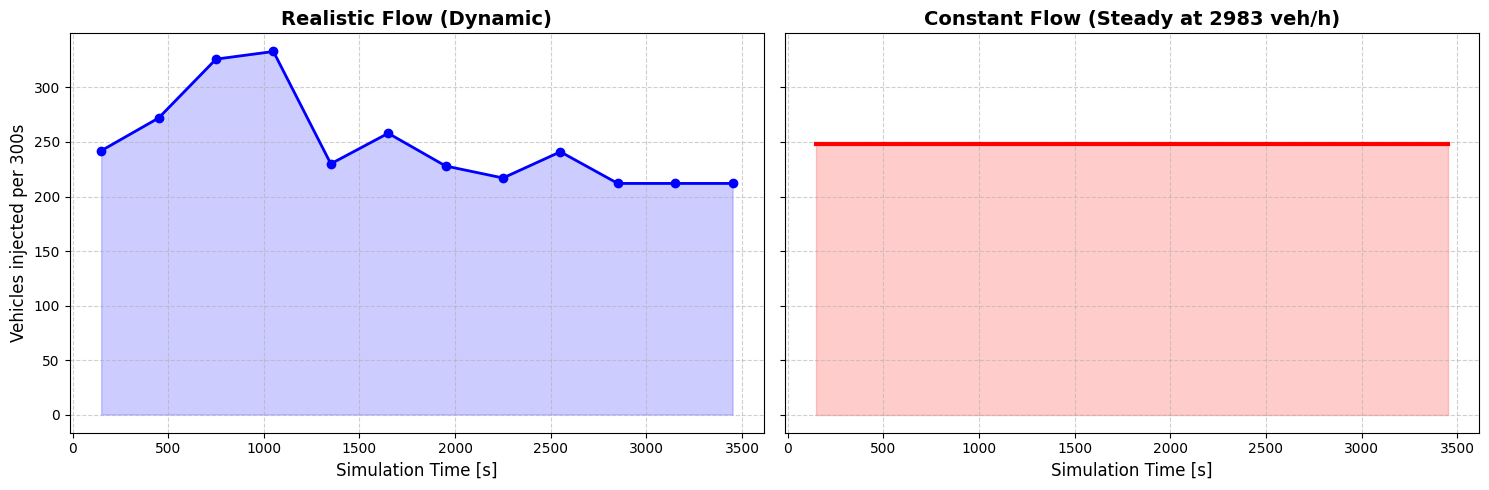

In [4]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURATION ---
REALISTIC_FILE = "env\map\hangzhou_4x4_gudang_18041610_1h.rou.xml" # Change to your actual file name
CONSTANT_FILE = "hangzhou_constant.rou.xml"   # Change to your actual file name
BIN_SIZE = 300 # Group vehicles into 5-minute (300s) bins for the plot
SIM_TIME = 3600

# --- 2. ANALYZE CONSTANT FLOW ---
tree_const = ET.parse(CONSTANT_FILE)
root_const = tree_const.getroot()

total_hourly_volume = 0
for flow in root_const.findall('flow'):
    total_hourly_volume += float(flow.get('vehsPerHour'))

print(f"--- CONSTANT FLOW STATS ---")
print(f"Total Network Volume: {total_hourly_volume} vehicles per hour")

# Calculate how many cars spawn per bin in the constant scenario
constant_cars_per_bin = total_hourly_volume * (BIN_SIZE / 3600)

# --- 3. ANALYZE REALISTIC FLOW ---
tree_real = ET.parse(REALISTIC_FILE)
root_real = tree_real.getroot()

realistic_departures = []
for vehicle in root_real.findall('vehicle'):
    depart = float(vehicle.get('depart'))
    if depart <= SIM_TIME:
        realistic_departures.append(depart)

print(f"--- REALISTIC FLOW STATS ---")
print(f"Total Network Volume: {len(realistic_departures)} vehicles in 1 hour")

# Group departures into bins
bins = np.arange(0, SIM_TIME + BIN_SIZE, BIN_SIZE)
real_counts, _ = np.histogram(realistic_departures, bins=bins)
bin_centers = bins[:-1] + (BIN_SIZE / 2)

# --- 4. PLOT FOR YOUR PAPER (Side-by-Side) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Plot 1: Realistic Flow
ax1.plot(bin_centers, real_counts, marker='o', color='blue', linewidth=2, label="Realistic Demand")
ax1.fill_between(bin_centers, real_counts, color='blue', alpha=0.2)
ax1.set_title("Realistic Flow (Dynamic)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Simulation Time [s]", fontsize=12)
ax1.set_ylabel(f"Vehicles injected per {BIN_SIZE}s", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Constant Flow
# The constant flow is a flat line across all bins
constant_line = [constant_cars_per_bin] * len(bin_centers)
ax2.plot(bin_centers, constant_line, color='red', linewidth=3, label="Constant Demand")
ax2.fill_between(bin_centers, constant_line, color='red', alpha=0.2)
ax2.set_title(f"Constant Flow (Steady at {int(total_hourly_volume)} veh/h)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Simulation Time [s]", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()